In [115]:
import pandas as pd
# from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import numpy as np

In [116]:
df = pd.read_csv('equity_large_cap_combined.csv')

In [117]:
df.set_index('Date',inplace= True)

In [118]:
df

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,285.60,294.733,25.76,54.08,161.3715,275.6116,66.652,37.6344,11.6941,35.8406,...,278.8764,256.446,40.010,23.53,33.7984,38.44,12.5059,43.3973,560.572,36.1920
2021-01-04,288.50,297.818,26.00,54.73,162.9652,278.7461,67.284,38.1749,11.8180,36.0912,...,280.9562,259.732,40.370,23.82,34.1958,38.71,12.6534,43.8852,567.097,36.3871
2021-01-05,289.50,300.004,26.16,55.03,163.8193,280.4760,67.753,38.2751,11.8936,36.2589,...,282.7030,261.038,40.620,24.03,34.3432,38.94,12.7395,44.1941,569.689,36.5095
2021-01-06,289.44,299.493,26.07,55.02,163.6768,280.1329,67.557,38.2382,11.8744,36.1293,...,281.6804,261.080,40.450,23.91,34.3456,38.92,12.7519,44.4256,569.845,36.4118
2021-01-07,290.10,299.103,26.05,55.26,163.8882,281.4667,67.588,38.4275,11.8967,36.0396,...,281.4998,259.986,40.410,23.92,34.3611,38.81,12.7789,44.8398,571.642,36.3918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-15,585.25,575.628,40.81,119.65,302.2655,582.1547,125.499,89.9069,19.3040,64.2312,...,544.7085,510.805,77.978,30.60,66.5690,83.82,20.4463,60.6253,1256.874,75.9128
2024-10-16,583.41,573.467,40.69,119.51,301.2589,581.3282,125.039,89.8298,19.2571,64.0786,...,542.1563,509.048,77.621,30.47,66.4205,83.62,20.3894,60.3907,1252.402,75.8799
2024-10-17,577.15,568.103,40.22,118.37,298.8784,574.7150,123.825,88.9684,19.1038,63.4482,...,536.0378,504.462,76.664,30.12,65.7693,82.76,20.2136,59.7761,1239.436,74.9361


In [119]:
df.index = pd.to_datetime(df.index)

In [120]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [121]:
multiindex_columns = [ 'NAV','DailyRet', '20DayRet', '20DayVol', 'Z20DayRet', 'Z20DayVol']
funds = df.columns 

In [122]:
dates = df.index

In [123]:
columns = pd.MultiIndex.from_product([funds, multiindex_columns],names=["Fund", "Metric"])

In [124]:
multiindex_df = pd.DataFrame(index=df.index, columns=columns)

In [125]:


# Initialize a dictionary to store calculated values
data_dict = {}

# Loop through each fund and compute metrics
for fund in funds:
    prices = df[fund]  # Extract price series
    
    # **Daily Returns**
    daily_ret = prices.pct_change()

    # **20-Day Rolling Return**
    ret_20d = prices.pct_change(20)

    # **20-Day Volatility (Rolling Standard Deviation of Daily Returns)**
    vol_20d = daily_ret.rolling(window=20).std(ddof=0)

    # **Z-score of 20-Day Returns**
    mean_252 = ret_20d.rolling(252).mean()
    std_252 = ret_20d.rolling(252).std(ddof=0)
    z_ret_20d = ((ret_20d - mean_252) / std_252).fillna(0)  

    # **Z-score of 20-Day Volatility**
    mean_vol_252 = vol_20d.rolling(252).mean()
    std_vol_252 = vol_20d.rolling(252).std(ddof=0)
    z_vol_20d = ((vol_20d - mean_vol_252) / std_vol_252).fillna(0)  

    # Store in dictionary
    data_dict[(fund, 'NAV')] = prices
    data_dict[(fund, 'DailyRet')] = daily_ret
    data_dict[(fund, '20DayRet')] = ret_20d
    data_dict[(fund, '20DayVol')] = vol_20d
    data_dict[(fund, 'Z20DayRet')] = z_ret_20d
    data_dict[(fund, 'Z20DayVol')] = z_vol_20d

# Create a MultiIndex DataFrame
multiindex_df = pd.DataFrame(data_dict)

# Sort MultiIndex columns for clarity
multiindex_df = multiindex_df.sort_index(axis=1, level=[0, 1])

# Display first few rows
# print(multiindex_df.head())


In [126]:
multiindex_df.head()

Aditya_large_cap                                                 \
                   20DayRet 20DayVol  DailyRet     NAV Z20DayRet Z20DayVol   
Date                                                                         
2021-01-01              NaN      NaN       NaN  285.60       0.0       0.0   
2021-01-04              NaN      NaN  0.010154  288.50       0.0       0.0   
2021-01-05              NaN      NaN  0.003466  289.50       0.0       0.0   
2021-01-06              NaN      NaN -0.000207  289.44       0.0       0.0   
2021-01-07              NaN      NaN  0.002280  290.10       0.0       0.0   

           Bandhan_large_cap                            ... UTI_large_cap  \
                    20DayRet 20DayVol  DailyRet    NAV  ...      DailyRet   
Date                                                    ...                 
2021-01-01               NaN      NaN       NaN  40.01  ...           NaN   
2021-01-04               NaN      NaN  0.008998  40.37  ...      0.009876   
2021-01-05               NaN      NaN  0.006193  40.62  ...      0.005241   
2021-01-06               NaN      NaN -0.004185  40.45  ...     -0.000870   
2021-01-07               NaN      NaN -0.000989  40.41  ...      0.001292   

                                         Union_large_cap                     \
                 NAV Z20DayRet Z20DayVol        20DayRet 20DayVol  DailyRet   
Date                                                                          
2021-01-01  161.3715       0.0       0.0             NaN      NaN       NaN   
2021-01-04  162.9652       0.0       0.0             NaN      NaN  0.008929   
2021-01-05  163.8193       0.0       0.0             NaN      NaN  0.005900   
2021-01-06  163.6768       0.0       0.0             NaN      NaN -0.002933   
2021-01-07  163.8882       0.0       0.0             NaN      NaN  0.000000   

                                       
              NAV Z20DayRet Z20DayVol  
Date                                   
2021-01-01  13.44       0.0       0.0  
2021-01-04  13.56       0.0       0.0  
2021-01-05  13.64       0.0       0.0  
2021-01-06  13.60       0.0       0.0  
2021-01-07  13.60       0.0       0.0  

[5 rows x 132 columns]

In [127]:
multiindex_df['Aditya_large_cap']['20DayRet'].nunique()

919

In [128]:
multiindex_df.shape

(939, 132)

In [129]:
full_feature_dataset = multiindex_df.dropna(axis = 0)

In [130]:
full_feature_dataset = full_feature_dataset.to_numpy()
full_feature_dataset.shape

(917, 132)

In [131]:
closing_prices = df.iloc[:full_feature_dataset.shape[0],:]

In [132]:
array_train, array_test = train_test_split(closing_prices, shuffle = False, test_size = .2)
# PCA_train, PCA_test = train_test_split(full_feature_dataset, shuffle = False, test_size = .2)

In [133]:
print(array_train.shape)
# print(PCA_train.shape)

(733, 22)


In [78]:
# pc3 = PCA()
# temp = pc3.fit_transform(PCA_train)

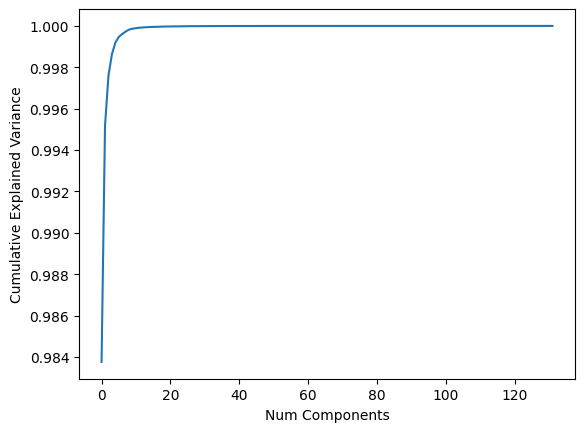

In [83]:
# plt.plot(np.cumsum(pc3.explained_variance_ratio_))
# plt.xlabel('Num Components')
# plt.ylabel('Cumulative Explained Variance');

In [134]:

#Data with only closing prices
from sklearn.preprocessing import MinMaxScaler
scl = MinMaxScaler()
scale = MinMaxScaler()
array_train = scl.fit_transform(array_train)
array_test  = scale.fit_transform(array_test) #[0,1]

# #Full features dataset; reducing dimensionality here
# from sklearn.decomposition import PCA
# pcTrain_scl = MinMaxScaler()
# pcTest_scl  = MinMaxScaler()
# pcaTrain = PCA(n_components = 22)
# pcaTest = PCA(n_components = 22)

# PCA_train = pcTrain_scl.fit_transform(PCA_train)
# PCA_train = pcaTrain.fit_transform(PCA_train)

# PCA_test = pcTest_scl.fit_transform(PCA_test)
# PCA_test = pcaTest.fit_transform(PCA_test)

In [135]:
print(array_train.shape)
# print(PCA_train.shape)

(733, 22)


In [136]:
def processData(data, lookback, horizon,num_companies,jump=1):
    X,Y = [],[]
    for i in range(0,len(data) -lookback - horizon +1, jump):
        X.append(data[i:(i+lookback)])
        Y.append(data[(i+lookback):(i+lookback+horizon)])
    return np.array(X),np.array(Y)

In [137]:
num_companies = df.shape[1]
lookback = 50 #How many days of the past can the model see
horizon = 4 #How many days into the future are we trying to predict

In [138]:

# Formation of lookback dataframes and forward dataframes for training, and testing dataset
# to calculate accuracy
# Formation of lookback dataframes and forward dataframes for training and testing dataset
# to calculate accuracy

# Testing Data
X_test, void = processData(array_test, lookback, horizon, num_companies, horizon)
void, y_test = processData(array_test, lookback, horizon, num_companies, horizon)
y_test = np.array([list(a.ravel()) for a in y_test])

# Training/Validation Data
X_train, void = processData(array_train, lookback, horizon, num_companies)
void, y = processData(array_train, lookback, horizon, num_companies)
y = np.array([list(x.ravel()) for x in y])

# Splitting into Train and Validation sets
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y, test_size=0.20, random_state=1)


In [139]:

print(X_train.shape)
print(X_validate.shape)
print(X_test.shape)
print(y_train.shape)
print(y_validate.shape)
print(y_test.shape)
#(Sample,Timestep,Features)

(544, 50, 22)
(136, 50, 22)
(33, 50, 22)
(544, 88)
(136, 88)
(33, 88)


In [140]:
from keras.models import Sequential, load_model
import tensorflow as tf
from keras.layers import LSTM,Dense,Activation,Attention,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import Regularizer
from keras import optimizers

#Model Architecture - Two LSTM layers with x neurons & y epochs
num_neurons_L1 = 600
num_neurons_L2 = 400
num_neurons_dense1 = 150
EPOCHS = 100

#Model
model = Sequential()

model.add(LSTM(num_neurons_L1,input_shape=(lookback,num_companies), return_sequences=True))
model.add(LSTM(num_neurons_L2,input_shape=(num_neurons_L1,1)))
model.add(Dense(horizon * num_companies, activation = 'relu'))
model.add(Dense(horizon * num_companies, activation = 'sigmoid'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics = ['accuracy'])

In [141]:
history = model.fit(X_train,y_train,epochs=EPOCHS,
                    validation_data=(X_validate,y_validate),
                    shuffle=False,batch_size=49, verbose=2)

Epoch 1/100


2025-03-28 07:31:06.342165: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:31:06.553551: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:31:06.645180: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:31:07.160534: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:31:07.258273: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:31:08.374704: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:31:08.431995: I tensorflow/core/grappler/optimizers/cust

12/12 - 4s - loss: 0.0338 - accuracy: 0.0221 - val_loss: 0.0302 - val_accuracy: 0.0809 - 4s/epoch - 331ms/step
Epoch 2/100
12/12 - 1s - loss: 0.0203 - accuracy: 0.0570 - val_loss: 0.0209 - val_accuracy: 0.1176 - 813ms/epoch - 68ms/step
Epoch 3/100
12/12 - 1s - loss: 0.0139 - accuracy: 0.0386 - val_loss: 0.0148 - val_accuracy: 0.0588 - 795ms/epoch - 66ms/step
Epoch 4/100
12/12 - 1s - loss: 0.0086 - accuracy: 0.0441 - val_loss: 0.0094 - val_accuracy: 0.0809 - 797ms/epoch - 66ms/step
Epoch 5/100
12/12 - 1s - loss: 0.0057 - accuracy: 0.0827 - val_loss: 0.0066 - val_accuracy: 0.1103 - 801ms/epoch - 67ms/step
Epoch 6/100
12/12 - 1s - loss: 0.0043 - accuracy: 0.1029 - val_loss: 0.0068 - val_accuracy: 0.1250 - 852ms/epoch - 71ms/step
Epoch 7/100
12/12 - 1s - loss: 0.0041 - accuracy: 0.1324 - val_loss: 0.0042 - val_accuracy: 0.1176 - 896ms/epoch - 75ms/step
Epoch 8/100
12/12 - 1s - loss: 0.0036 - accuracy: 0.1048 - val_loss: 0.0031 - val_accuracy: 0.1397 - 856ms/epoch - 71ms/step
Epoch 9/100
12

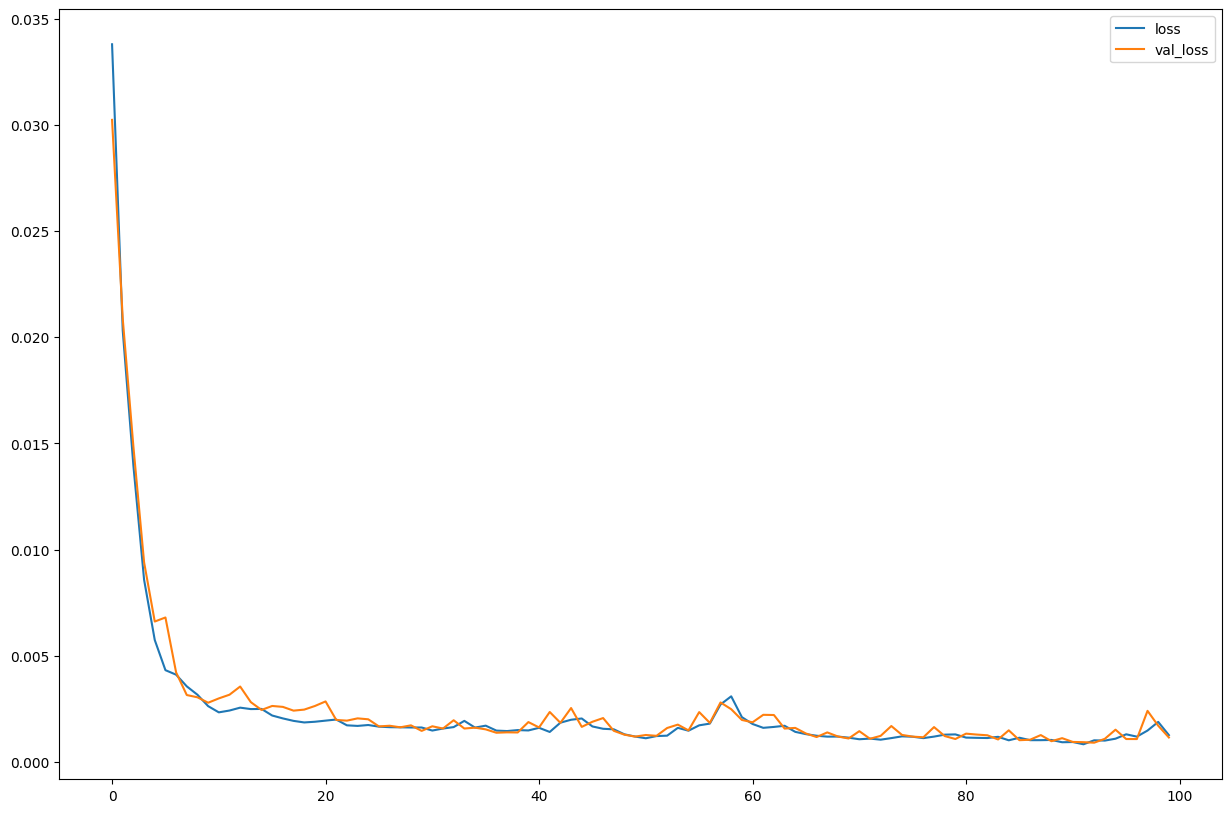

In [142]:

plt.figure(figsize = (15,10))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='best')
plt.show()

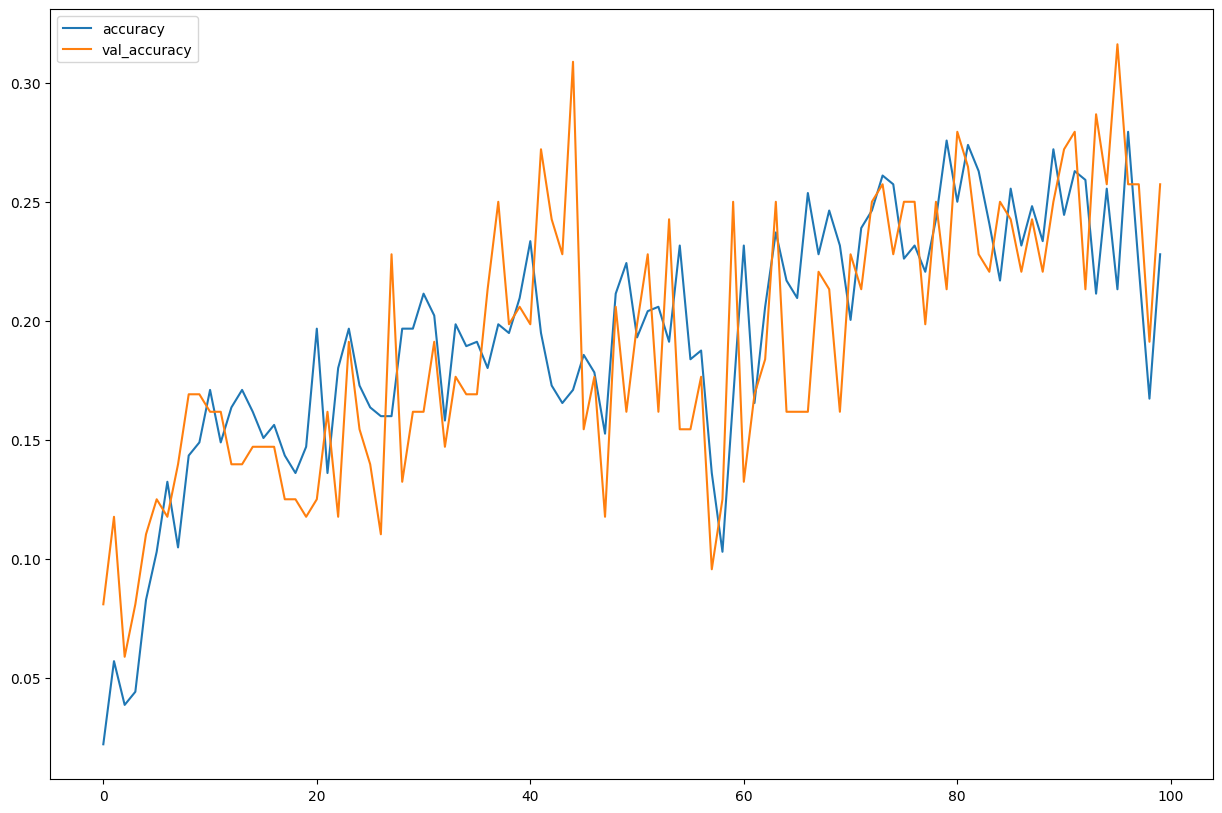

In [143]:

plt.figure(figsize = (15,10))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend(loc='best')
plt.show()

In [144]:
X_test, void = processData(array_test,lookback,horizon,num_companies,horizon)
void, y_test = processData(array_test,lookback,horizon,num_companies,horizon) 
y_test = np.array([list(a.ravel()) for a in y_test])


Xt = model.predict(X_test)
Xt.shape

2025-03-28 07:33:16.011288: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:33:16.073936: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-28 07:33:16.150644: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 1s 88ms/step


(33, 88)

In [145]:
#Aux function 1
def do_inverse_transform(output_result,num_companies):
    #transform to input shape
    original_matrix_format = []
    for result in output_result:
        #do inverse transform
        original_matrix_format.append(scl.inverse_transform([result[x:x+num_companies] for x in range(0, len(result), num_companies)]))
    original_matrix_format = np.array(original_matrix_format)
    
    #restore to original shape
    for i in range(len(original_matrix_format)):
        output_result[i] = original_matrix_format[i].ravel()

    return output_result

In [146]:

#Aux function 2
def prediction_by_step_by_company(raw_model_output, num_companies):
    matrix_prediction = []
    for i in range(0,num_companies):
        matrix_prediction.append([[lista[j] for j in range(i,len(lista),num_companies)] for lista in raw_model_output])
    return np.array(matrix_prediction)

In [147]:

#Aux function 3
def target_by_company(raw_model_output, num_companies):
    matrix_target = [[] for x in range(num_companies)]
    
    for output in raw_model_output:
        for i in range (num_companies):
            for j in range(0,len(output),num_companies):
                matrix_target[i].append(output[i+j])
    return np.array(matrix_target)

In [148]:
Xt = do_inverse_transform(Xt, num_companies)
predictions = prediction_by_step_by_company(Xt, num_companies)
predictions.shape

(22, 33, 4)

In [149]:

Yt = do_inverse_transform(y_test, num_companies)

actuals = target_by_company(Yt, num_companies)
actuals.shape

(22, 132)

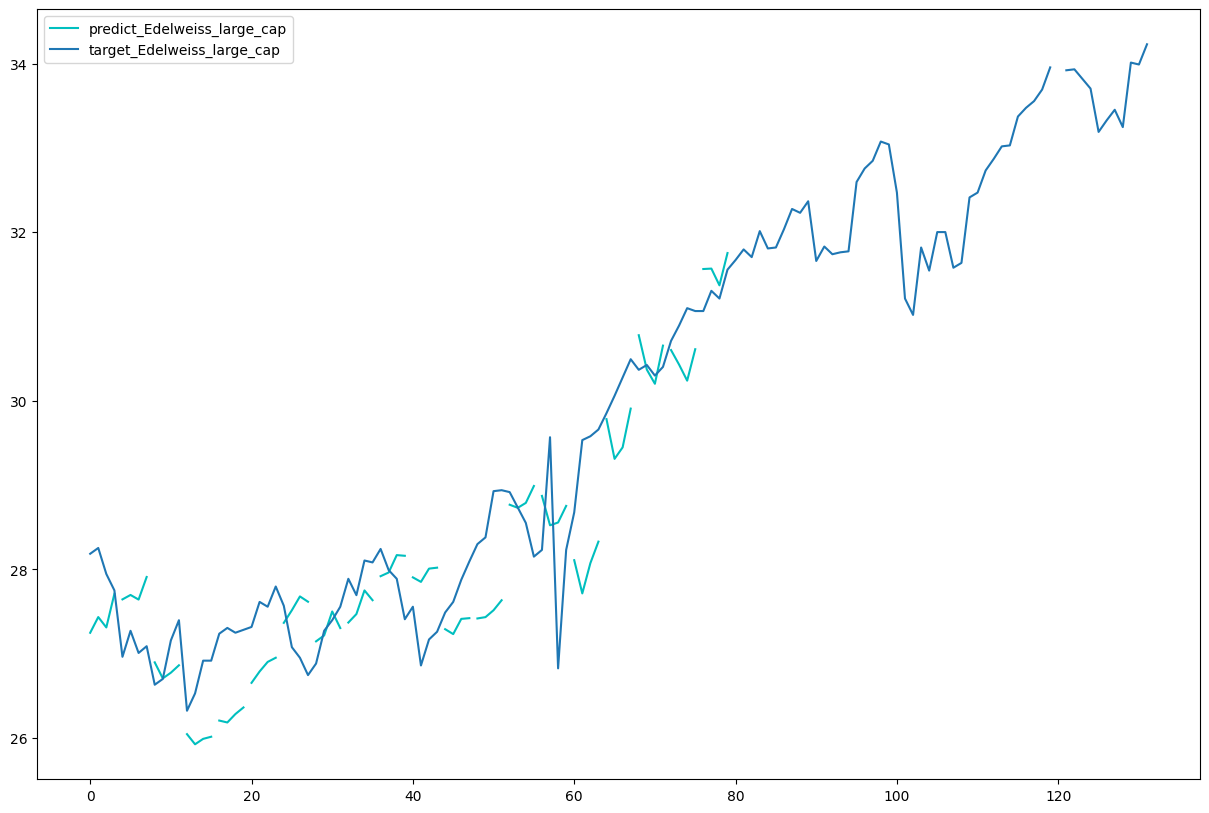

In [150]:
plt.figure(figsize = (15,10))

companies_to_show = [2] 
colors = ['r','g','c','m','y','k','w','b']
companies_names = ['Aditya_large_cap', 'Kotak_Bluechip_large_cap', 'Edelweiss_large_cap','ICICI_large_cap']
 
for id_company in companies_to_show:
    for i in range(0,len(predictions[id_company])):
        plt.plot([x + i*horizon for x in range(len(predictions[id_company][i]))], predictions[id_company][i], color=colors[id_company])
    plt.plot(0,predictions[id_company][0][0] ,color=colors[id_company], label='predict_{}'.format(companies_names[id_company])) #only to place the label

   

for id_company in companies_to_show:
    plt.plot(actuals[id_company], label='target_{}'.format(companies_names[id_company]))

plt.legend(loc='best')
plt.show()
     

In [151]:
funds

Index(['Aditya_large_cap', 'Kotak_Bluechip_large_cap', 'Edelweiss_large_cap',
       'ICICI_large_cap', 'UTI_large_cap', 'Tata_large_cap', 'Mirae_large_cap',
       'Nippon_large_cap', 'Sundaram_large_cap', 'LIC_large_cap',
       'Union_large_cap', 'Canara_large_cap', 'HSBC_large_cap',
       'DSP_large_cap', 'Bandhan_large_cap', 'PGIM_large_cap',
       'SBI_bluechip_large_cap', 'Invesco_large_cap', 'Mahindra_large_cap',
       'Franklin_large_cap', 'HDFC_large_cap', 'JM_large_cap'],
      dtype='object')

In [111]:

# full_PCA = np.concatenate((PCA_train,PCA_test),axis = 0)

In [113]:
# X_all,void = processData(full_PCA,lookback,horizon,num_companies,horizon)
# void,y_all = processData(scl.fit_transform(df),lookback,horizon,num_companies,horizon)
# y_all = np.array([list(a.ravel()) for a in y_all])

In [152]:
# Step 1: Scale the full dataset (Train + Test)
full_scaled = scl.fit_transform(closing_prices)  # Scaling original data instead of PCA

# Step 2: Generate Lookback Data for LSTM
X_all, void = processData(full_scaled, lookback, horizon, num_companies, horizon)

# Step 3: Prepare Target Variable (y_all)
void, y_all = processData(full_scaled, lookback, horizon, num_companies, horizon)
y_all = np.array([list(a.ravel()) for a in y_all])

In [153]:
Xt = model.predict(X_all)
Xt.shape

7/7 [==============================] - 0s 25ms/step


(216, 88)

In [154]:
Xt = do_inverse_transform(Xt, num_companies)

predictions = prediction_by_step_by_company(Xt, num_companies)
predictions.shape

(22, 216, 4)

In [155]:
Yt = do_inverse_transform(y_all, num_companies)

actuals = target_by_company(Yt, num_companies)
actuals.shape

(22, 864)

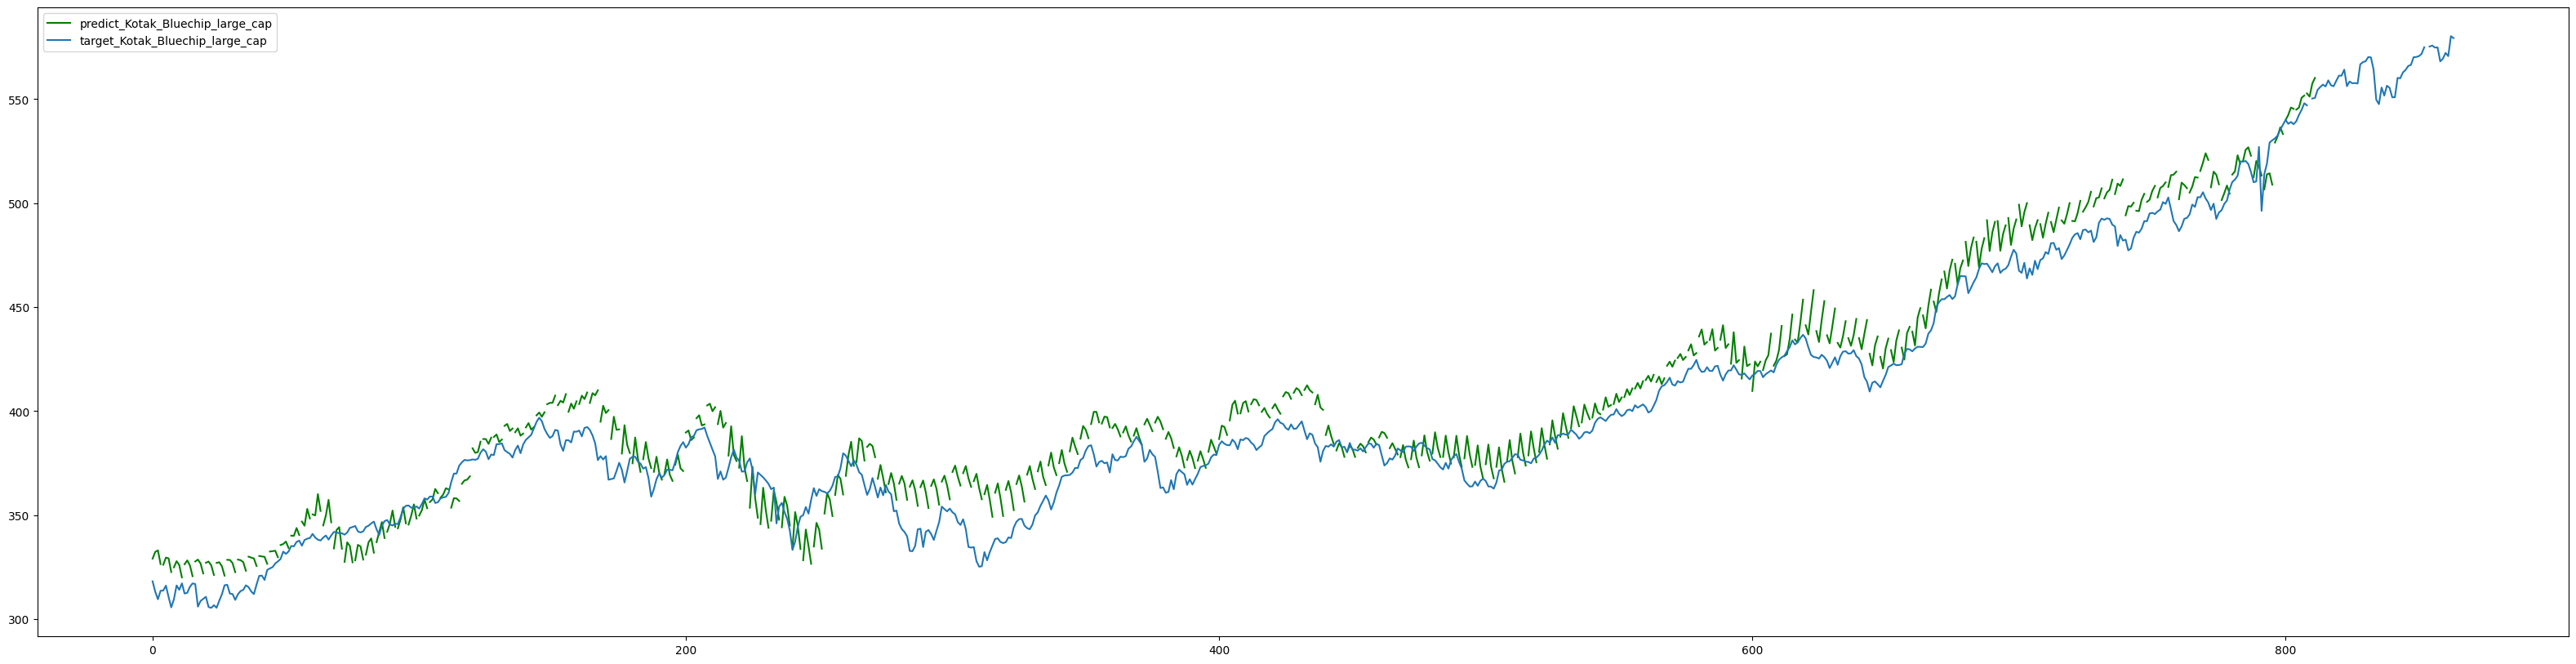

In [156]:

plt.figure(figsize = (40,10))

companies_to_show = [1] #Type a number between 0:4 to see 4 different companies
colors = ['r','g','c','m','y','k','w','b']
companies_names = ['Aditya_large_cap', 'Kotak_Bluechip_large_cap', 'Edelweiss_large_cap','ICICI_large_cap']

    
for id_company in companies_to_show:
    for i in range(0,len(predictions[id_company])):
        plt.plot([x + i*horizon for x in range(len(predictions[id_company][i]))], predictions[id_company][i], color=colors[id_company])
    plt.plot(0,predictions[id_company][0][0] ,color=colors[id_company], label='predict_{}'.format(companies_names[id_company])) #only to place the label

   

for id_company in companies_to_show:
    plt.plot(actuals[id_company], label='target_{}'.format(companies_names[id_company]))

plt.legend(loc='best')
plt.show()

In [157]:
predicted_prices = np.zeros((predictions.shape[1]*predictions.shape[2],predictions.shape[0]))
# actual_prices = []

for i in range(predictions.shape[0]):
  counter = 0
  for j in range(predictions.shape[1]):
    for z in range(predictions.shape[2]):
      predicted_prices[counter, i] = predictions[i,j,z]
      counter+=1

print(counter)

864


In [158]:
actuals_prices = actuals[:,:864].T

In [159]:
print(predicted_prices.shape)
print(actuals_prices.shape)
print(dates.shape)

(864, 22)
(864, 22)
(939,)


In [160]:
(939-lookback+1)-864

26

In [161]:
actual_prices = pd.DataFrame(data = actuals_prices, columns = funds,index = dates[lookback+1:940-25])
predicted_prices = pd.DataFrame(data = predicted_prices,columns=funds, index = dates[lookback+1:940-25])

In [162]:
pd.reset_option('display.max_rows',None)

In [183]:
actual_prices

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,307.13,318.259,27.30,58.65,171.5540,306.2308,71.759,41.5618,12.5492,37.0192,...,295.5225,269.013,42.010,24.92,36.6855,40.82,13.7459,45.4693,624.924,37.6685
2021-03-18,302.61,313.250,26.92,57.82,169.5837,301.3506,70.883,40.8112,12.3860,36.5867,...,291.2305,264.868,41.560,24.59,36.1505,40.16,13.5363,44.6914,613.871,37.3264
2021-03-19,298.97,309.623,26.58,57.24,167.4880,297.5813,69.865,40.2576,12.2243,36.1494,...,287.4747,261.812,41.090,24.28,35.7451,39.56,13.3778,44.2760,607.348,37.0455
2021-03-22,302.01,313.717,26.84,57.81,169.2965,300.8599,70.686,40.7037,12.3525,36.4681,...,290.6743,264.319,41.510,24.55,36.1025,39.97,13.5256,44.6636,613.714,37.3680
2021-03-23,302.39,313.792,26.81,57.73,169.4733,300.6411,70.635,40.7267,12.3708,36.4199,...,290.0655,264.712,41.570,24.58,36.1512,39.87,13.5189,44.7239,612.024,37.3513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-10,578.05,569.475,41.48,118.84,303.4092,579.8395,125.317,88.9320,19.4968,64.0142,...,533.9525,506.191,77.641,31.55,65.1588,82.26,20.7770,59.7036,1245.808,76.2121
2024-09-11,580.71,572.225,41.59,119.24,304.8290,582.9200,126.018,89.6201,19.5751,64.3197,...,536.2579,507.575,78.082,31.68,65.3814,82.78,20.8522,60.1371,1253.010,76.4772
2024-09-12,577.94,570.666,41.41,118.75,303.9768,579.7624,125.500,89.2029,19.4996,64.0120,...,533.2236,504.866,77.854,31.62,65.2547,82.69,20.7251,59.9298,1245.711,76.0186


In [195]:
pd.reset_option('display.max_rows',None)

In [189]:
predicted_prices

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,315.891083,329.134155,26.725687,60.908421,179.277466,315.855591,73.185089,42.952438,12.883682,38.203857,...,299.811310,278.249542,42.330452,25.100414,37.499363,41.743397,14.557983,46.521702,631.573120,39.237164
2021-03-18,315.030151,332.386810,26.546160,59.767406,178.362289,322.026123,74.054039,42.014374,13.070023,38.474888,...,300.910767,283.500305,42.811707,25.172081,36.917202,41.562801,14.471734,46.479492,639.641541,39.381729
2021-03-19,319.930573,333.127716,26.608732,61.328487,179.244629,321.681793,73.589638,43.170460,12.976474,38.571304,...,299.981873,284.811768,43.022827,25.285677,37.881508,41.897518,14.758592,47.049961,640.080322,38.498646
2021-03-22,321.230621,326.537048,27.124418,60.865017,181.502716,324.163269,74.542046,43.428696,13.153436,38.498215,...,304.668732,286.404114,43.284241,25.750334,38.147881,42.891636,14.929151,46.611946,650.248413,39.048641
2021-03-23,313.287354,326.210022,26.523308,60.352207,177.487823,313.186157,72.585403,42.532921,12.731430,37.806141,...,296.843231,275.948883,42.052101,24.815725,37.140106,41.274101,14.337282,45.847511,626.637756,38.982357
2021-03-24,311.328308,329.654633,26.343061,59.429123,176.793243,318.246979,73.292717,41.655712,12.933292,38.051750,...,298.608246,281.233887,42.462887,24.927517,36.692295,41.083584,14.284880,45.923042,635.067017,39.182583
2021-03-25,317.005981,329.282257,26.432495,60.707729,177.130035,318.213531,72.978897,42.698700,12.834892,38.165085,...,297.890289,281.619995,42.635815,24.958277,37.555138,41.390022,14.538949,46.344086,632.874634,38.263741
2021-03-26,318.467896,322.704254,26.876043,60.003029,179.573059,321.184906,73.616867,42.901634,12.977510,38.015263,...,301.261871,282.895081,42.947182,25.360880,37.828587,42.397861,14.659176,45.938385,644.995117,38.694633
2021-03-30,312.162048,324.978333,26.387909,59.967979,176.757416,311.464294,72.246986,42.216377,12.629370,37.508186,...,294.496674,274.890625,41.863659,24.598309,36.914314,40.876259,14.156746,45.441990,623.704346,38.888039


In [185]:
closing_prices

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,285.60,294.733,25.76,54.08,161.3715,275.6116,66.652,37.6344,11.6941,35.8406,...,278.8764,256.446,40.010,23.53,33.7984,38.44,12.5059,43.3973,560.572,36.1920
2021-01-04,288.50,297.818,26.00,54.73,162.9652,278.7461,67.284,38.1749,11.8180,36.0912,...,280.9562,259.732,40.370,23.82,34.1958,38.71,12.6534,43.8852,567.097,36.3871
2021-01-05,289.50,300.004,26.16,55.03,163.8193,280.4760,67.753,38.2751,11.8936,36.2589,...,282.7030,261.038,40.620,24.03,34.3432,38.94,12.7395,44.1941,569.689,36.5095
2021-01-06,289.44,299.493,26.07,55.02,163.6768,280.1329,67.557,38.2382,11.8744,36.1293,...,281.6804,261.080,40.450,23.91,34.3456,38.92,12.7519,44.4256,569.845,36.4118
2021-01-07,290.10,299.103,26.05,55.26,163.8882,281.4667,67.588,38.4275,11.8967,36.0396,...,281.4998,259.986,40.410,23.92,34.3611,38.81,12.7789,44.8398,571.642,36.3918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-12,587.94,580.265,42.08,120.66,308.4768,587.8327,127.564,90.5238,19.8616,65.0955,...,543.0019,512.016,79.147,32.13,66.4042,83.98,21.0419,60.9009,1269.507,77.2521
2024-09-13,587.04,579.342,42.06,120.50,308.2263,586.8973,127.532,90.3875,19.8459,64.9322,...,542.2787,512.188,79.213,32.07,66.4349,83.97,20.9875,60.8880,1266.233,77.2594
2024-09-16,587.55,579.539,42.27,120.80,308.4807,588.2346,127.801,90.4034,19.8589,64.9735,...,544.7873,512.310,79.093,32.10,66.4929,84.05,21.0114,61.0079,1272.532,77.1742


In [108]:
from sklearn.metrics import mean_squared_error

In [109]:
predicted_returns = predicted_prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]
actual_returns = actual_prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]
closing_returns = closing_prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]

In [73]:
mean_squared_error(predicted_returns, actual_returns)

ValueError: Input contains NaN.

In [81]:
filtered = predicted_returns[predicted_returns.isna()]

In [87]:
predicted_prices_filter = predicted_returns[predicted_returns.isna().any(axis=1)]


In [110]:
from sklearn.metrics import mean_squared_error

# Drop rows with NaNs from both predicted and actual returns
valid_indices = ~predicted_returns.isna() & ~actual_returns.isna()

# Filter valid (non-NaN) values
predicted_returns_clean = predicted_returns[valid_indices]
actual_returns_clean = actual_returns[valid_indices]

# Compute MSE
mse = mean_squared_error(predicted_returns_clean, actual_returns_clean)
print("Mean Squared Error:", mse)


ValueError: Input contains NaN.

In [112]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure both are Pandas Series
predicted_returns = predicted_returns.astype(float)
actual_returns = actual_returns.astype(float)

# Drop NaNs properly
valid_indices = predicted_returns.notna() & actual_returns.notna()

# Apply valid indices
predicted_returns_clean = predicted_returns[valid_indices]
actual_returns_clean = actual_returns[valid_indices]

# Ensure no NaNs remain
assert predicted_returns_clean.isna().sum() == 0, "NaNs still present in predicted_returns_clean"
assert actual_returns_clean.isna().sum() == 0, "NaNs still present in actual_returns_clean"

# Compute MSE
mse = mean_squared_error(predicted_returns_clean, actual_returns_clean)
print("Mean Squared Error:", mse)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [113]:
predicted_returns_clean

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-18,-0.006986,0.016601,-0.017570,-0.003063,-0.007052,0.001077,0.007249,-0.017868,0.015906,0.008543,...,0.002622,0.001071,-0.006433,0.006939,0.000445,-0.006619,-0.001665,-0.011985,-0.012335,-0.005949
2021-03-19,0.027590,-0.008586,0.012899,-0.004886,0.012124,-0.001940,-0.000790,0.029382,-0.019568,-0.006023,...,-0.001040,0.005335,0.003371,0.007531,-0.003091,0.007774,0.008231,0.008802,-0.008532,-0.002606
2021-03-22,0.009223,0.009964,0.009004,0.004287,-0.001676,0.008095,-0.016622,-0.002093,0.005619,0.008696,...,-0.009577,0.004670,0.019335,-0.010242,0.007413,-0.007500,0.000350,0.000502,0.014320,0.008442
2021-03-23,-0.037126,-0.026395,-0.010253,-0.001881,-0.010820,-0.016085,0.000596,-0.019361,-0.009852,-0.018885,...,0.000627,-0.019414,-0.022147,-0.012354,-0.013380,-0.003581,-0.015493,-0.007024,-0.001726,-0.005038
2021-03-24,-0.007610,0.017821,-0.016587,-0.004564,-0.005906,-0.000258,0.008859,-0.014052,0.016245,0.010603,...,0.003938,0.002348,-0.007805,0.007363,0.003098,-0.007078,-0.002884,-0.012478,-0.014292,-0.006216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28,-0.010376,-0.008364,0.004632,-0.022049,0.001248,-0.016865,0.023808,-0.002115,-0.012543,-0.003665,...,-0.000380,0.032249,0.026862,-0.018197,-0.004599,0.009616,0.008622,-0.034543,0.002744,-0.007020
2024-06-30,0.029331,0.026731,0.027290,0.017766,0.025221,0.019566,0.008088,0.024237,0.021434,0.000819,...,0.010367,0.023442,0.009804,0.024264,0.026462,0.017005,0.005672,0.024728,0.027064,0.036632
2024-07-01,NaN,NaN,-0.018051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.021132,NaN,-0.011305,NaN,NaN,NaN,NaN,NaN


In [178]:
filtered = predicted_prices[predicted_prices.isna().any(axis=1)]


In [179]:
filtered

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,


In [177]:
predicted_prices = predicted_prices.dropna()


In [181]:
actual_prices = actual_prices.dropna()

In [184]:
closing_prices = closing_prices.dropna()

In [190]:
valid_indices = predicted_prices.index.intersection(actual_prices.index).intersection(closing_prices.index)
actual_prices = actual_prices.loc[valid_indices]
predicted_prices = predicted_prices.loc[valid_indices]
closing_prices = closing_prices.loc[valid_indices]

In [191]:
print(actual_prices.shape)
print(predicted_prices.shape)
print(closing_prices.shape)

(810, 22)
(810, 22)
(810, 22)


In [192]:
predicted_returns = predicted_prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]
actual_returns = actual_prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]

In [198]:
actual_returns[actual_returns.isna().any(axis=1)]

,Aditya_large_cap,Kotak_Bluechip_large_cap,Edelweiss_large_cap,ICICI_large_cap,UTI_large_cap,Tata_large_cap,Mirae_large_cap,Nippon_large_cap,Sundaram_large_cap,LIC_large_cap,...,HSBC_large_cap,DSP_large_cap,Bandhan_large_cap,PGIM_large_cap,SBI_bluechip_large_cap,Invesco_large_cap,Mahindra_large_cap,Franklin_large_cap,HDFC_large_cap,JM_large_cap
Date,,,,,,,,,,,,,,,,,,,,,


In [200]:

from sklearn.metrics import mean_squared_error
mean_squared_error(actual_prices,predicted_prices)

70.93870984967533

In [201]:

#Mean Returns function
def mean_returns(df, length): 
  mu = df.sum(axis = 0)/length
  return mu

In [202]:
from datetime import timedelta
from dateutil.parser import parse

def monthdelta(date, delta):
    m, y = (date.month+delta) % 12, date.year + ((date.month)+delta-1) // 12
    if not m: m = 12
    d = min(date.day, [31,
        29 if y%4==0 and not y%400==0 else 28,31,30,31,30,31,31,30,31,30,31][m-1])
    new_date = (date.replace(day=d,month=m, year=y))
    return parse(new_date.strftime('%Y-%m-%d'))


#This part of the code takes in a dataset and splits it into datasets w/ lookback months and forward looking months
def windowGenerator (dataframe, lookback, horizon,
                    step, cummulative = False):

#takes pandas dataframe with DatetimeIndex

    if cummulative:
        c = lookback
        step = horizon
        
    initial = min(dataframe.index)
    windows = []
    horizons = []

    while initial <= monthdelta(max(dataframe.index), -lookback):
        windowStart = initial
        windowEnd = monthdelta(windowStart, lookback)
        if cummulative:
            windowStart = min(dataframe.index)
            windowEnd = monthdelta(windowStart, c) + timedelta(days=1)
            c += horizon
        horizonStart = windowEnd + timedelta(days=1)
        horizonEnd = monthdelta(horizonStart, horizon)

        lookbackWindow = dataframe[windowStart:windowEnd]
        horizonWindow = dataframe[horizonStart:horizonEnd]

        windows.append(lookbackWindow)
        horizons.append(horizonWindow)

        initial = monthdelta(initial, step)

    return windows, horizons

In [203]:
from scipy.optimize import minimize, Bounds, LinearConstraint
from numpy.linalg import norm

def actual_return(actual_returns, w):
  actual_returns = actual_returns
  mean_return = mean_returns(actual_returns, actual_returns.shape[0])
  actual_covariance = actual_returns.cov()

  portfolio_returns = mean_return.T.dot(w)
  portfolio_variance = w.T.dot(actual_covariance).dot(w)
  return portfolio_returns, portfolio_variance


#Input entire predicted returns df, actual returns df, starting date
def scipy_opt(predicted_returns, actual_returns, lam1, lam2):
  mean_return = mean_returns(predicted_returns, predicted_returns.shape[0])
  predicted_covariance = predicted_returns.cov()
  
  #Cost Function
  def f(w):
    return -(mean_return.T.dot(w) - lam1*(w.T.dot(predicted_covariance).dot(w)) + lam2*norm(w, ord=1))
  #out custom maximises 

  #Bounds of Weights
  opt_bounds = Bounds(0, 1)

  #Equality Constraints
  def h(w):
    return sum(w) - 1

  #Constraints Dictionary
  cons = ({
      'type' : 'eq',
      'fun' : lambda w: h(w)
  })

  #Solver
  sol = minimize(f,
                 x0 = np.ones(mean_return.shape[0]),
                 constraints = cons,
                 bounds = opt_bounds,
                 options = {'disp': False},
                 tol=10e-10)


  #Predicted Results
  w = sol.x
  predicted_portfolio_returns = w.dot(mean_return)
  portfolio_STD = w.T.dot(predicted_covariance).dot(w)
  
  #Actual Results
  portfolio_actual_returns, portfolio_actual_variance = actual_return(actual_returns, w)
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)

  ret_dict = {'weights' : w,
              'predicted_returns' : predicted_portfolio_returns,
              'predicted_variance' : portfolio_STD,
              'actual_returns' : portfolio_actual_returns,
              'actual_variance' : portfolio_actual_variance,
              'sharpe_ratio': sharpe_ratio}
  
  return ret_dict

In [204]:
LSTM_pred_windows, LSTM_pred_horizons = windowGenerator(predicted_returns,12,1,1)
LSTM_act_windows, LSTM_act_horizons = windowGenerator(actual_returns,12,1,1)

In [205]:
len(LSTM_pred_horizons)

28

In [206]:
scipy_returns= []
scipy_variance = []
scipy_SR = []


for i in range(len(LSTM_act_horizons)-60,len(LSTM_act_horizons)):
  #Scipy optimize results
  scipy = scipy_opt(LSTM_pred_horizons[i], LSTM_act_horizons[i], .5, 2)
  scipy_returns.append(scipy['actual_returns'])
  scipy_variance.append(scipy['actual_variance'])
  scipy_SR.append(scipy['sharpe_ratio'])
  print("Month " + str(i) + " complete")

IndexError: list index out of range